In [1]:
import random
import torch
import numpy as np


手撕ROPE

In [2]:
#Q*exp(i*m*theta) , K*exp(i*m*theta)  m就是position  theta = 10000^(-2i/d)

seq_len = 10
dim = 128
Q = torch.randn(seq_len,dim)
K = torch.randn(seq_len,dim)

#分成俩波，分别做sin,cos操作
Q_split = Q.view(Q.shape[0],-1,2)
K_split = K.view(Q.shape[0],-1,2)

print(Q_split.shape,K_split.shape)

torch.Size([10, 64, 2]) torch.Size([10, 64, 2])


In [3]:
#theta = 10000^(-2i/d)

rope_theta = 10000
d_2 = dim//2
#index = (-2i/d)
index = torch.tensor(range(d_2))/d_2
print(index)

tensor([0.0000, 0.0156, 0.0312, 0.0469, 0.0625, 0.0781, 0.0938, 0.1094, 0.1250,
        0.1406, 0.1562, 0.1719, 0.1875, 0.2031, 0.2188, 0.2344, 0.2500, 0.2656,
        0.2812, 0.2969, 0.3125, 0.3281, 0.3438, 0.3594, 0.3750, 0.3906, 0.4062,
        0.4219, 0.4375, 0.4531, 0.4688, 0.4844, 0.5000, 0.5156, 0.5312, 0.5469,
        0.5625, 0.5781, 0.5938, 0.6094, 0.6250, 0.6406, 0.6562, 0.6719, 0.6875,
        0.7031, 0.7188, 0.7344, 0.7500, 0.7656, 0.7812, 0.7969, 0.8125, 0.8281,
        0.8438, 0.8594, 0.8750, 0.8906, 0.9062, 0.9219, 0.9375, 0.9531, 0.9688,
        0.9844])


In [4]:
#x^(-2i/d) = 1.0/x^2i/d
freqs = 1.0 / (rope_theta**index)
print(freqs)

tensor([1.0000e+00, 8.6596e-01, 7.4989e-01, 6.4938e-01, 5.6234e-01, 4.8697e-01,
        4.2170e-01, 3.6517e-01, 3.1623e-01, 2.7384e-01, 2.3714e-01, 2.0535e-01,
        1.7783e-01, 1.5399e-01, 1.3335e-01, 1.1548e-01, 1.0000e-01, 8.6596e-02,
        7.4989e-02, 6.4938e-02, 5.6234e-02, 4.8697e-02, 4.2170e-02, 3.6517e-02,
        3.1623e-02, 2.7384e-02, 2.3714e-02, 2.0535e-02, 1.7783e-02, 1.5399e-02,
        1.3335e-02, 1.1548e-02, 1.0000e-02, 8.6596e-03, 7.4989e-03, 6.4938e-03,
        5.6234e-03, 4.8697e-03, 4.2170e-03, 3.6517e-03, 3.1623e-03, 2.7384e-03,
        2.3714e-03, 2.0535e-03, 1.7783e-03, 1.5399e-03, 1.3335e-03, 1.1548e-03,
        1.0000e-03, 8.6596e-04, 7.4989e-04, 6.4938e-04, 5.6234e-04, 4.8697e-04,
        4.2170e-04, 3.6517e-04, 3.1623e-04, 2.7384e-04, 2.3714e-04, 2.0535e-04,
        1.7783e-04, 1.5399e-04, 1.3335e-04, 1.1548e-04])


In [6]:
# A=[1, m], B=[1, n], outer(A, B) = [m, n]

position = torch.arange(seq_len)
freqs_for_each_token = torch.outer(position, freqs)
freqs_cis = torch.polar(torch.ones_like(freqs_for_each_token), freqs_for_each_token)
print(freqs_for_each_token.shape)
print(freqs_for_each_token[2])
print(freqs_cis[2])

torch.Size([10, 64])
tensor([2.0000e+00, 1.7319e+00, 1.4998e+00, 1.2988e+00, 1.1247e+00, 9.7394e-01,
        8.4339e-01, 7.3035e-01, 6.3246e-01, 5.4768e-01, 4.7427e-01, 4.1071e-01,
        3.5566e-01, 3.0799e-01, 2.6670e-01, 2.3096e-01, 2.0000e-01, 1.7319e-01,
        1.4998e-01, 1.2988e-01, 1.1247e-01, 9.7394e-02, 8.4339e-02, 7.3035e-02,
        6.3246e-02, 5.4768e-02, 4.7427e-02, 4.1071e-02, 3.5566e-02, 3.0799e-02,
        2.6670e-02, 2.3096e-02, 2.0000e-02, 1.7319e-02, 1.4998e-02, 1.2988e-02,
        1.1247e-02, 9.7394e-03, 8.4339e-03, 7.3035e-03, 6.3246e-03, 5.4768e-03,
        4.7427e-03, 4.1071e-03, 3.5566e-03, 3.0799e-03, 2.6670e-03, 2.3096e-03,
        2.0000e-03, 1.7319e-03, 1.4998e-03, 1.2988e-03, 1.1247e-03, 9.7394e-04,
        8.4339e-04, 7.3035e-04, 6.3246e-04, 5.4768e-04, 4.7427e-04, 4.1070e-04,
        3.5566e-04, 3.0799e-04, 2.6670e-04, 2.3096e-04])
tensor([-0.4161+9.0930e-01j, -0.1604+9.8705e-01j,  0.0709+9.9748e-01j,
         0.2687+9.6323e-01j,  0.4315+9.0213e-01j,  

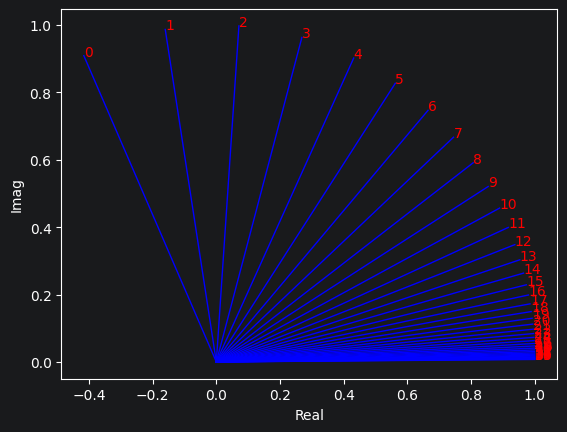

In [7]:
import matplotlib.pyplot as plt

display = 40

# 看第3个位置的频率分布
value = freqs_cis[2]

plt.figure()
for idx, element in enumerate(value[:display]):
    plt.plot([0, element.real], [0, element.imag], color='blue', linewidth=1, label=f"Index: {idx}")
    plt.annotate(f"{idx}", xy=(element.real, element.imag), color='red')

plt.xlabel("Real")
plt.ylabel("Imag")
plt.show()

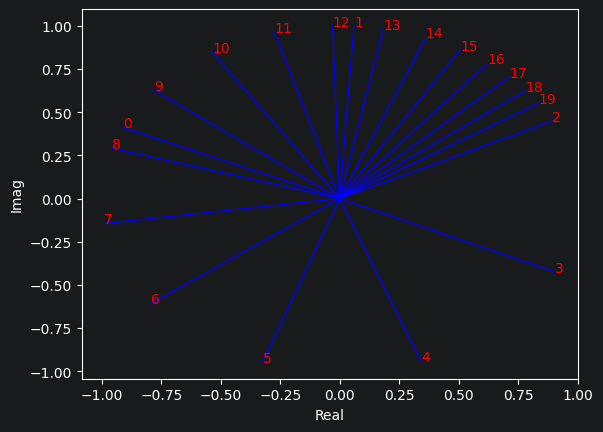

In [8]:
# 看第10个位置的频率分布
value = freqs_cis[9]
display = 20
plt.figure()
for idx, element in enumerate(value[:display]):
    plt.plot([0, element.real], [0, element.imag], color='blue', linewidth=1, label=f"Index: {idx}")
    plt.annotate(f"{idx}", xy=(element.real, element.imag), color='red')

plt.xlabel("Real")
plt.ylabel("Imag")
plt.show()

对Q,K做旋转

In [9]:
#实数转复数 执行旋转乘法 复数转回实数 恢复原始形状。
Q_split_comp = torch.view_as_complex(Q_split)
Q_split_rotated_real = torch.view_as_real(Q_split_comp * freqs_cis)#要保留实数
Q_split_rotated = Q_split_rotated_real.view(Q.shape)
print(Q_split_rotated_real.shape, Q_split_rotated.shape)

torch.Size([10, 64, 2]) torch.Size([10, 128])


In [10]:
K_split_comp = torch.view_as_complex(K_split)
K_split_rotated_real = torch.view_as_real(K_split_comp * freqs_cis)
K_split_rotated = K_split_rotated_real.view(K.shape)
print(K_split_rotated_real.shape, K_split_rotated.shape)

torch.Size([10, 64, 2]) torch.Size([10, 128])


In [11]:
qk = torch.matmul(Q_split_rotated, K_split_rotated.T) / (K.shape[1]) ** 0.5
qk.shape

torch.Size([10, 10])

In [12]:
qk

tensor([[-0.7641, -0.8947,  0.0788,  1.3774, -0.2071,  0.2276,  0.7614,  0.9301,
         -1.1127,  0.6376],
        [ 1.2011, -0.3435,  1.2708, -0.6847, -1.7784, -0.0574, -0.8039, -0.2668,
          0.1289,  1.0092],
        [-0.0740, -1.6485,  2.5845,  0.4995, -1.6271,  0.9664, -0.4181, -0.1849,
         -0.2677,  1.5199],
        [-1.1689,  0.0801,  0.0490,  0.7035, -1.7437, -1.0065,  0.2156, -1.0940,
          0.9966,  0.2748],
        [ 1.3241,  0.7613, -0.0348,  1.0824, -0.7267, -1.0716,  0.5806, -0.4149,
          1.4086,  0.8986],
        [ 0.4552, -0.0414, -0.3445,  1.2718, -1.3742, -0.3359,  0.9853, -0.1734,
         -0.4105, -0.8348],
        [-0.1003,  0.0381,  0.1966, -0.0848,  0.0849,  0.5805,  0.0702,  0.4569,
         -0.1986,  1.0372],
        [ 0.2714,  0.1965, -0.1256,  0.9071, -0.3659, -0.8921, -2.3726,  0.8999,
          0.9165,  1.4251],
        [ 0.7521, -0.0275, -2.9287,  0.5581,  0.3349,  0.9246, -0.8083, -1.1702,
          0.9047, -1.7099],
        [ 1.0622,  

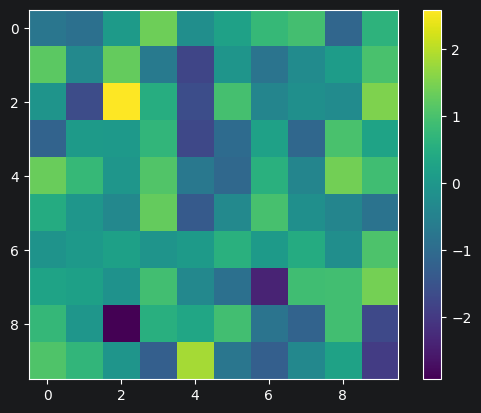

In [13]:
def display_qk_heatmap(qk):
    qk = qk.detach().cpu().numpy()
    _, ax = plt.subplots()
    im = ax.imshow(qk, cmap="viridis")
    ax.figure.colorbar(im, ax=ax)

display_qk_heatmap(qk)

加入掩码机制

In [14]:
#意力分数矩阵 Attention_Scores 的形状是 [seq_len, seq_len]
mask = torch.full((seq_len,seq_len),float('-inf'))
mask = torch.triu(mask, diagonal=1)
mask

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

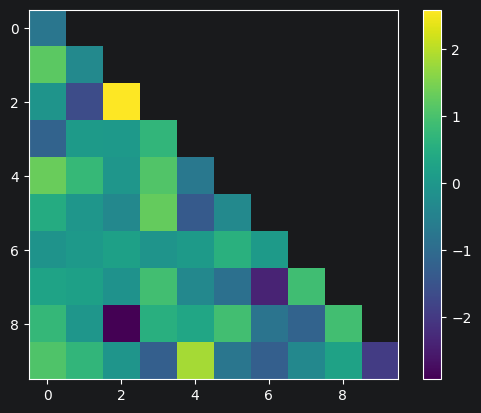

In [15]:
qk_mask = qk + mask
display_qk_heatmap(qk_mask)

ROPE远程衰减

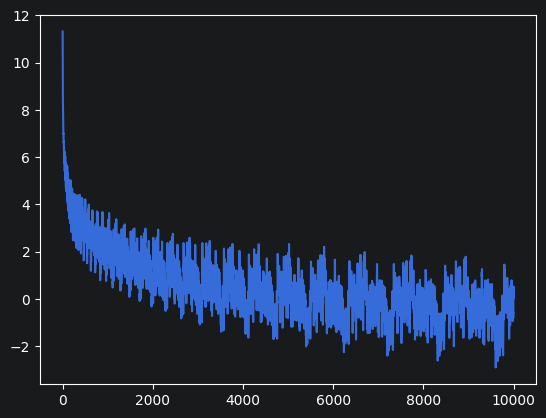

In [1]:
import torch
import matplotlib.pylab as plt
import numpy

rope_theta = 10000
#Q*exp(i*m*theta) , K*exp(i*m*theta)  m就是position  theta = 10000^(-2i/d)
def rotatry(max_tokens, query_index, dim):

    Q = torch.ones(max_tokens,dim)
    K = torch.ones(max_tokens,dim)
    Q_split = Q.view(Q.shape[0],-1,2)
    K_split = K.view(K.shape[0],-1,2)

    d_2 = dim//2
    index = torch.arange(d_2)/d_2
    freqs = 1.0/(rope_theta**index)
    position = torch.arange(max_tokens)
    freqs_for_each_token = torch.outer(position,freqs)
    freqs_cis = torch.polar(torch.ones_like(freqs_for_each_token), freqs_for_each_token)

    Q_split_comp = torch.view_as_complex(Q_split)
    Q_split_rotated_real = torch.view_as_real(Q_split_comp * freqs_cis)
    Q_split_rotated = Q_split_rotated_real.view(Q.shape)

    K_split_comp = torch.view_as_complex(K_split)
    K_split_rotated_real = torch.view_as_real(K_split_comp * freqs_cis)
    K_split_rotated = K_split_rotated_real.view(K.shape)

    qk = torch.matmul(Q_split_rotated, K_split_rotated.T) / (K.shape[1]) ** 0.5
    return qk[query_index]

max_tokens = 10000
query_index = 0
dim = 128

attn_scores = rotatry(max_tokens, query_index, dim)
attn_scores = attn_scores.detach().cpu().numpy()
plt.plot(attn_scores)